In [1]:
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, precision_recall_curve

import pandas as pd

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
drive_path = "/content/drive/MyDrive/AstroStats/"
table_gal_qso = pd.read_csv(drive_path+"galaxyquasar.csv")

Mounted at /content/drive


In [3]:
table_gal_qso

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
# Assign unique integers from 0 to 1 to each object type (GAL or QSO)
le = LabelEncoder()
table_gal_qso['class'] = le.fit_transform(table_gal_qso['class'])
labels = le.inverse_transform(table_gal_qso['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [5]:
table_gal_qso

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,1,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,0,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,0,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,0,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,1,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,0,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,0,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,0,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,0,0.112571,0.000009


In [6]:
table_gal_qso.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       50000 non-null  float64
 1   g       50000 non-null  float64
 2   r       50000 non-null  float64
 3   i       50000 non-null  float64
 4   z       50000 non-null  float64
 5   class   50000 non-null  int64  
 6   z1      50000 non-null  float64
 7   zerr    50000 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 3.1 MB


In [7]:
# remember sklearn requires format (n_samples, n_features)
x1 = np.array(table_gal_qso["u"])-np.array(table_gal_qso["g"])
x2 = np.array(table_gal_qso["g"])-np.array(table_gal_qso["r"])
x3 = np.array(table_gal_qso["r"])-np.array(table_gal_qso["i"])
x4 = np.array(table_gal_qso["i"])-np.array(table_gal_qso["z"])
y = np.array(table_gal_qso["class"])
#X = np.array([x1]).T
#X = np.array([x1, x2]).T
#X = np.array([x1, x2, x3]).T
X = np.array([x1, x2, x3, x4]).T

In [8]:
# Split the dataset in tranining + test dataset
X_CV, X_test, y_CV, y_test, CV_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.1, random_state=42)

In [9]:
print(X_CV.shape)
print(X_test.shape)

(45000, 4)
(5000, 4)


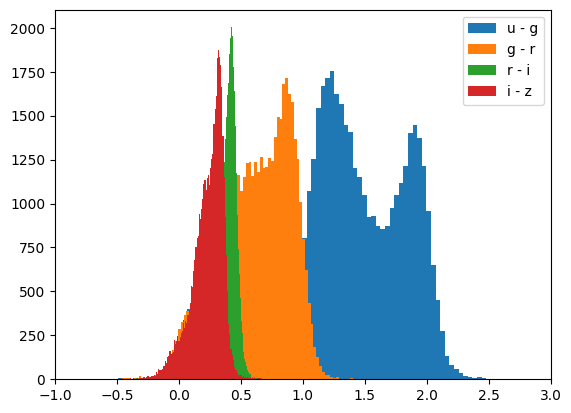

In [10]:
plt.hist(X_CV[:, 0], bins="auto", label="u - g")
plt.hist(X_CV[:, 1], bins="auto", label="g - r")
plt.hist(X_CV[:, 2], bins="auto", label="r - i")
plt.hist(X_CV[:, 3], bins="auto", label="i - z")
plt.legend(loc="upper right")
plt.xlim(-1, 3)
plt.show()
plt.close()

In [11]:
# Use cross validation to tune hyperparameters such as the number of neighbors K
scores = []
Kvals = np.arange(1,20)
for K in Kvals:
    clf = KNeighborsClassifier(n_neighbors=K)
    CVpredK = cross_val_predict(clf, X_CV, y_CV)
    scores.append(accuracy_score(y_CV, CVpredK))

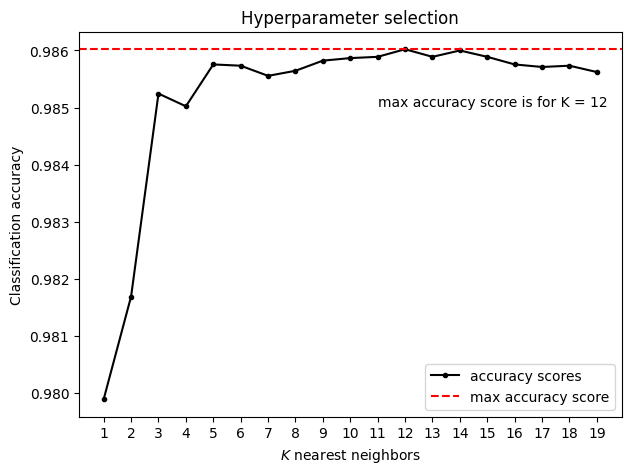

In [12]:
# Plot number of neighbors vs score
fig = plt.figure(figsize=(7, 5))
u = np.arange(len(scores))+1
plt.plot(u, scores, ".-k", label="accuracy scores")
plt.xticks(u)
plt.xlabel('$K$ nearest neighbors')
plt.ylabel('Classification accuracy')
plt.title('Hyperparameter selection')
plt.text(11, scores[np.argmax(scores)]-0.001, "max accuracy score is for K = {:d}".format(Kvals[np.argmax(scores)]))
plt.axhline(y=scores[np.argmax(scores)], color='r', linestyle='--', label="max accuracy score")
plt.legend()
plt.show()

Metric:        | Measures:                    | Focuses On:             | Useful When:
---------------|------------------------------|-------------------------|-----------------------------------------
Accuracy       | Overall correctness          | All classes             | Classes are balanced
Precision      | Correctness of positives     | False positives         | False positives are costly
Recall         | Coverage of actual positives | False negatives         | False negatives are costly


In [13]:
tuned_K = Kvals[np.argmax(scores)]
# Final KNeighborsClassifier fit with tuned hyperparameter K
knc = KNeighborsClassifier(tuned_K)
knc.fit(X_CV, y_CV)
# Predict KNeighborsClassifier on test dataset
y_pred_knc = knc.predict(X_test)
# For performance you need the probabilities (e.g. of class 1), not the class predictions themselves
y_prob_knc = knc.predict_proba(X_test)[:, 1]

In [14]:
print("accuracy knc: {:.3f}".format(accuracy_score(y_test, y_pred_knc)))
print("precision knc: {:.3f}".format(precision_score(y_test, y_pred_knc)))
print("recall knc: {:.3f}".format(recall_score(y_test, y_pred_knc)))

accuracy knc: 0.985
precision knc: 0.962
recall knc: 0.930


In [15]:
gnb = GaussianNB()
gnb.fit(X_CV, y_CV)
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

In [16]:
print("accuracy gnb: {:.3f}".format(accuracy_score(y_test, y_pred_gnb)))
print("precision gnb: {:.3f}".format(precision_score(y_test, y_pred_gnb)))
print("recall gnb: {:.3f}".format(recall_score(y_test, y_pred_gnb)))

accuracy gnb: 0.975
precision gnb: 0.898
recall gnb: 0.922


In [17]:
lda = LDA()
lda.fit(X_CV, y_CV)
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]

In [18]:
print("accuracy lda: {:.3f}".format(accuracy_score(y_test, y_pred_lda)))
print("precision lda: {:.3f}".format(precision_score(y_test, y_pred_lda)))
print("recall lda: {:.3f}".format(recall_score(y_test, y_pred_lda)))

accuracy lda: 0.981
precision lda: 0.940
recall lda: 0.918


In [19]:
qda = QDA()
qda.fit(X_CV, y_CV)
y_pred_qda = qda.predict(X_test)
y_prob_qda = qda.predict_proba(X_test)[:, 1]

In [20]:
print("accuracy qda: {:.3f}".format(accuracy_score(y_test, y_pred_qda)))
print("precision qda: {:.3f}".format(precision_score(y_test, y_pred_qda)))
print("recall qda: {:.3f}".format(recall_score(y_test, y_pred_qda)))

accuracy qda: 0.981
precision qda: 0.941
recall qda: 0.918


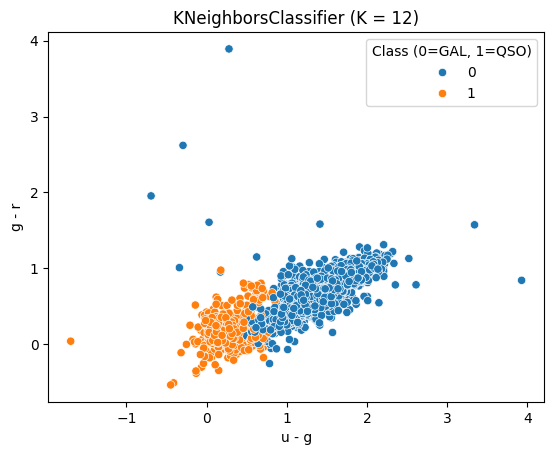

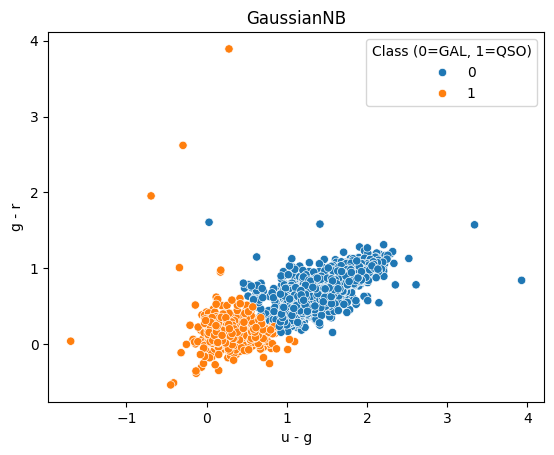

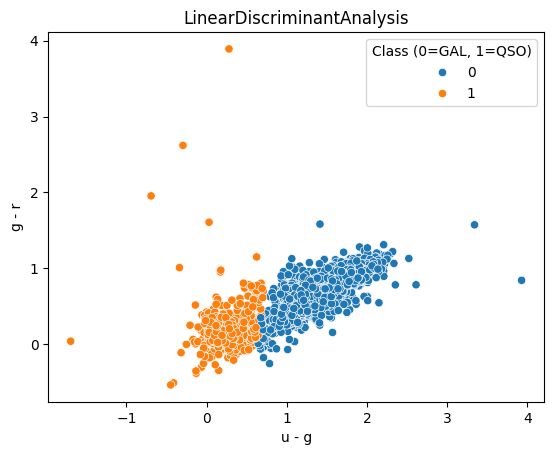

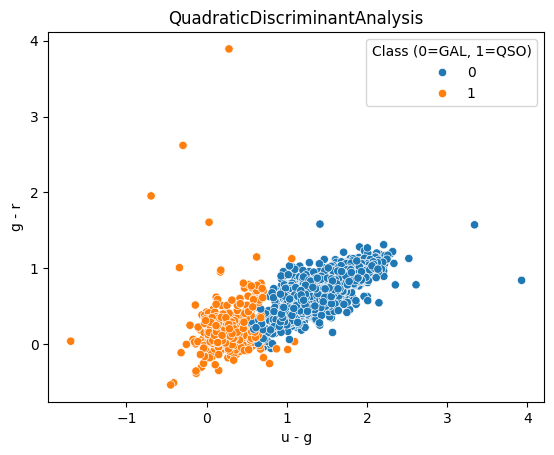

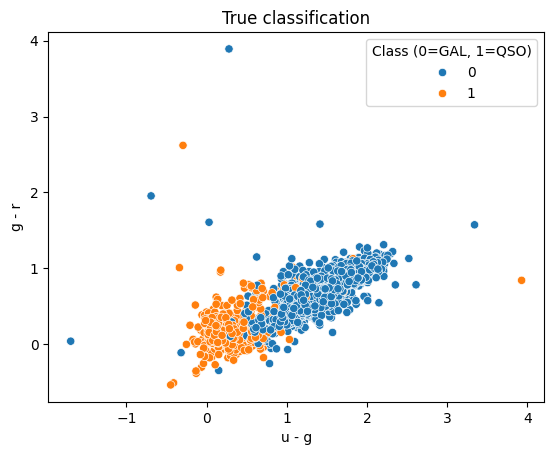

In [21]:
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_knc)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("KNeighborsClassifier (K = 12)")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_gnb)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("GaussianNB")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_lda)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("LinearDiscriminantAnalysis")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_qda)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("QuadraticDiscriminantAnalysis")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test)
plt.legend(title="Class (0=GAL, 1=QSO)")
plt.title("True classification")
plt.xlabel("u - g")
plt.ylabel("g - r")
plt.show()

In [22]:
fpr_knc, tpr_knc, thresh1_knc = roc_curve(y_test, y_prob_knc)
precision_knc, recall_knc, thresh2_knc = precision_recall_curve(y_test, y_prob_knc)

fpr_gnb, tpr_gnb, thresh1_gnb = roc_curve(y_test, y_prob_gnb)
precision_gnb, recall_gnb, thresh2_gnb = precision_recall_curve(y_test, y_prob_gnb)

fpr_lda, tpr_lda, thresh1_lda = roc_curve(y_test, y_prob_lda)
precision_lda, recall_lda, thresh2_lda = precision_recall_curve(y_test, y_prob_lda)

fpr_qda, tpr_qda, thresh1_qda = roc_curve(y_test, y_prob_qda)
precision_qda, recall_qda, thresh2_qda = precision_recall_curve(y_test, y_prob_qda)

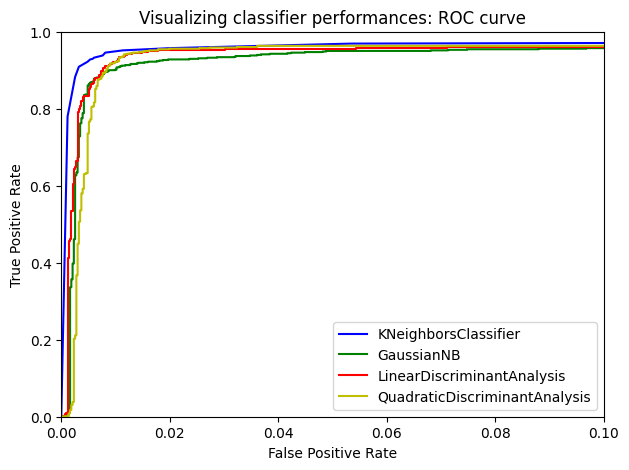

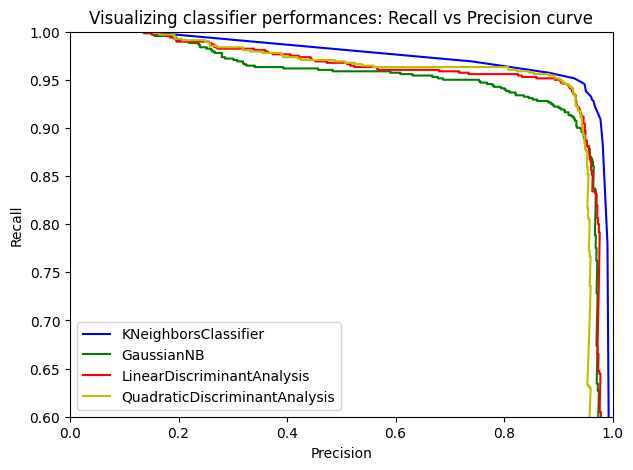

In [23]:
plt.figure(figsize=(7, 5))
plt.title("Visualizing classifier performances: ROC curve")
plt.plot(fpr_knc, tpr_knc, "b-", label="KNeighborsClassifier")
plt.plot(fpr_gnb, tpr_gnb, "g-", label="GaussianNB")
plt.plot(fpr_lda, tpr_lda, "r-", label="LinearDiscriminantAnalysis")
plt.plot(fpr_qda, tpr_qda, "y-", label="QuadraticDiscriminantAnalysis")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 0.1)
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.plot(precision_knc, recall_knc, "b-", label="KNeighborsClassifier")
plt.plot(precision_gnb, recall_gnb, "g-", label="GaussianNB")
plt.plot(precision_lda, recall_lda, "r-", label="LinearDiscriminantAnalysis")
plt.plot(precision_qda, recall_qda, "y-", label="QuadraticDiscriminantAnalysis")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.xlim(0, 1)
plt.ylim(0.6, 1)
plt.legend()
plt.show()

Precision at 90% : 0.930
Recall at 90% precision : 0.952
Threshold at 90% precision : 0.167


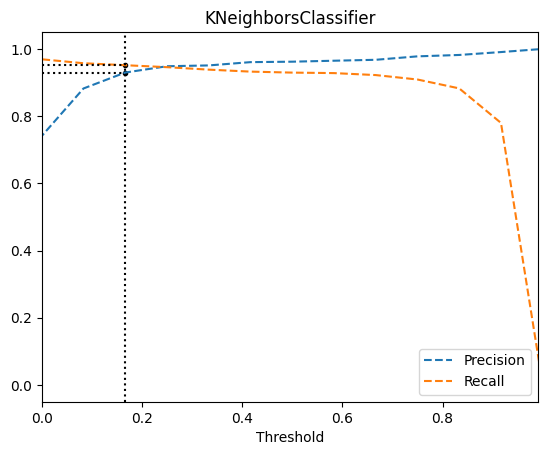

Precision at 90% : 0.901
Recall at 90% precision : 0.922
Threshold at 90% precision : 0.514


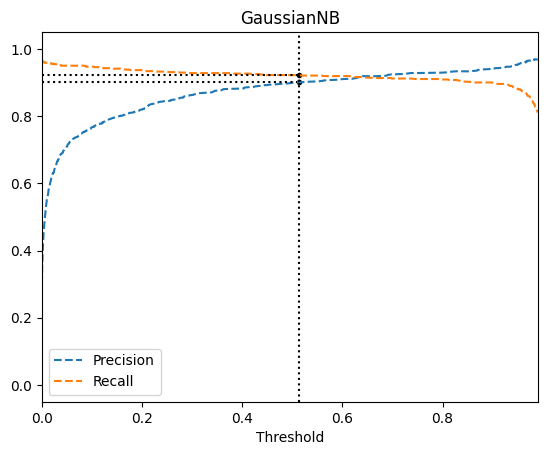

Precision at 90% : 0.901
Recall at 90% precision : 0.950
Threshold at 90% precision : 0.195


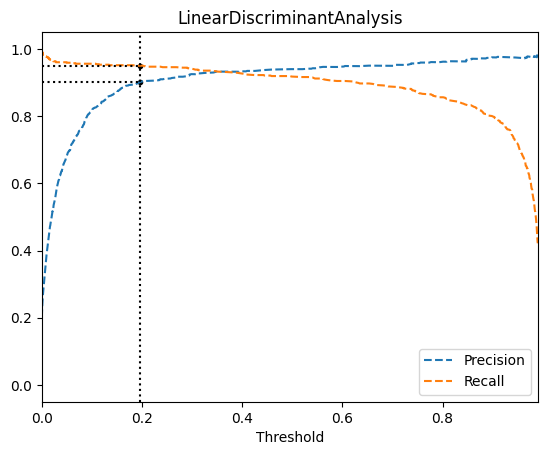

Precision at 90% : 0.900
Recall at 90% precision : 0.952
Threshold at 90% precision : 0.146


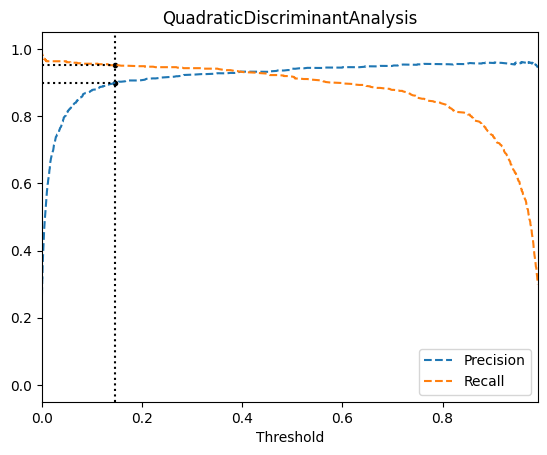

In [24]:
thresh2_knc = np.insert(thresh2_knc, 0, 0.0)

rec_90_prec = recall_knc[np.argmax(precision_knc >= 0.90)]
thresh_90_prec = thresh2_knc[np.argmax(precision_knc >= 0.90)]
prec_90_prec = precision_knc[np.argmax(precision_knc >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_knc, precision_knc, "--", label="Precision")
plt.plot(thresh2_knc, recall_knc, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("KNeighborsClassifier")
plt.xlabel("Threshold")
plt.xlim(0, 0.99)
plt.legend()
plt.show()
plt.close()

thresh2_gnb = np.insert(thresh2_gnb, 0, 0.0)

rec_90_prec = recall_gnb[np.argmax(precision_gnb >= 0.90)]
thresh_90_prec = thresh2_gnb[np.argmax(precision_gnb >= 0.90)]
prec_90_prec = precision_gnb[np.argmax(precision_gnb >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_gnb, precision_gnb, "--", label="Precision")
plt.plot(thresh2_gnb, recall_gnb, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("GaussianNB")
plt.xlabel("Threshold")
plt.xlim(0, 0.99)
plt.legend()
plt.show()
plt.close()

thresh2_lda = np.insert(thresh2_lda, 0, 0.0)

rec_90_prec = recall_lda[np.argmax(precision_lda >= 0.90)]
thresh_90_prec = thresh2_lda[np.argmax(precision_lda >= 0.90)]
prec_90_prec = precision_lda[np.argmax(precision_lda >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_lda, precision_lda, "--", label="Precision")
plt.plot(thresh2_lda, recall_lda, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("LinearDiscriminantAnalysis")
plt.xlabel("Threshold")
plt.xlim(0, 0.99)
plt.legend()
plt.show()
plt.close()

thresh2_qda = np.insert(thresh2_qda, 0, 0.0)

rec_90_prec = recall_qda[np.argmax(precision_qda >= 0.90)]
thresh_90_prec = thresh2_qda[np.argmax(precision_qda >= 0.90)]
prec_90_prec = precision_qda[np.argmax(precision_qda >= 0.90)]
print("Precision at 90% : {:.3f}".format(prec_90_prec))
print("Recall at 90% precision : {:.3f}".format(rec_90_prec))
print("Threshold at 90% precision : {:.3f}".format(thresh_90_prec))

plt.plot(thresh2_qda, precision_qda, "--", label="Precision")
plt.plot(thresh2_qda, recall_qda, "--", label="Recall")
plt.axhline(y=prec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axhline(y=rec_90_prec, color='k', linestyle=':', xmin=0, xmax=thresh_90_prec)
plt.axvline(x=thresh_90_prec, color='k', linestyle=':')
plt.scatter(thresh_90_prec, prec_90_prec, color='k', marker=".")
plt.scatter(thresh_90_prec, rec_90_prec, color='k', marker=".")
plt.title("QuadraticDiscriminantAnalysis")
plt.xlabel("Threshold")
plt.xlim(0, 0.99)
plt.legend()
plt.show()
plt.close()